# Adversarial PPO Analysis

Use this notebook to visualize training logs for the adversarial PPO cartpole agent and to generate rollout videos with the nonlinear MPSC safety filter.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

NOTEBOOK_DIR = Path.cwd()

# Use the same model path as adv_experiment.py: models/rl_models/{system}/{task}/{algo}/
# For cartpole tracking with PPO:
DEFAULT_LOG_DIR = (NOTEBOOK_DIR / "models/rl_models/cartpole/track/ppo").resolve()
DEFAULT_OUTPUT_DIR = DEFAULT_LOG_DIR / "plots"
DEFAULT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using log directory: {DEFAULT_LOG_DIR}")
print(f"Figures will be saved under: {DEFAULT_OUTPUT_DIR}")

Using log directory: /home/admin05/safe-control-gym/experiments/adversarial/models/rl_models/cartpole/track/ppo
Figures will be saved under: /home/admin05/safe-control-gym/experiments/adversarial/models/rl_models/cartpole/track/ppo/plots


Saved summary figure to /home/admin05/safe-control-gym/experiments/adversarial/models/rl_models/cartpole/track/ppo/plots/training_summary.png


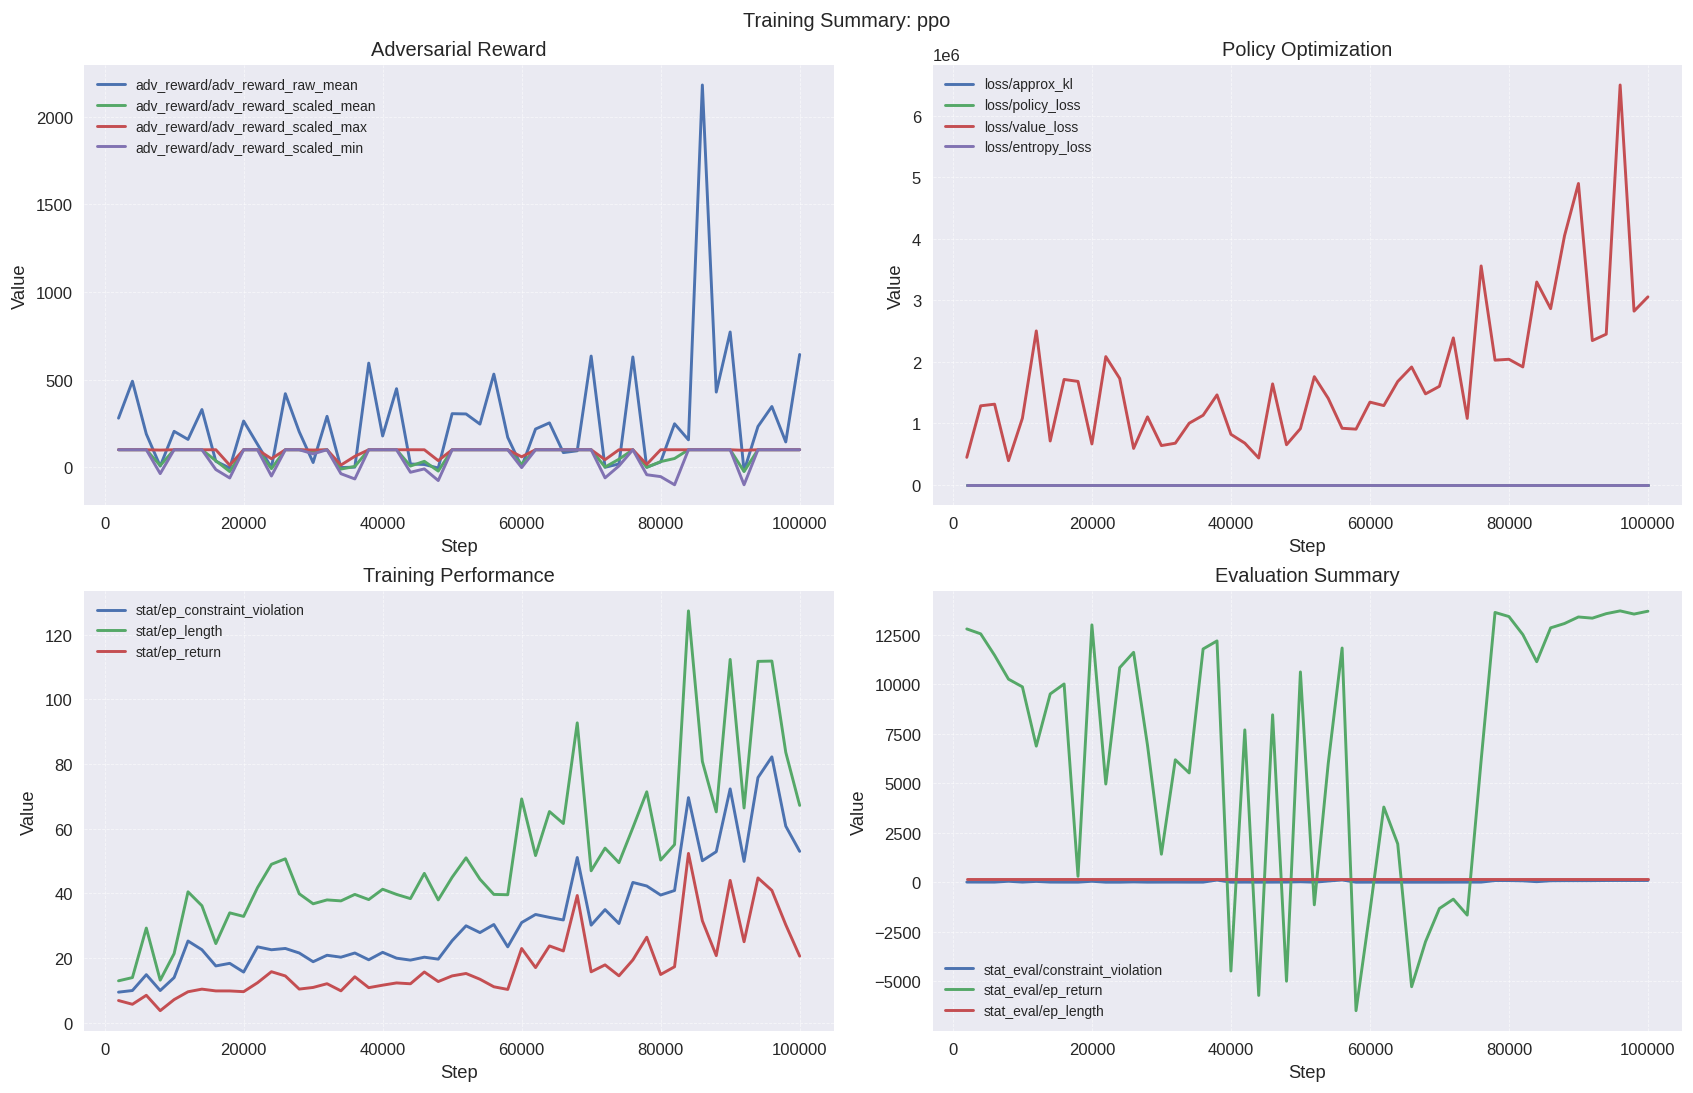

In [2]:
from typing import Dict, List, Optional

PLOT_GROUPS: Dict[str, List[str]] = {
    "Adversarial Reward": [
        "adv_reward/adv_reward_raw_mean",
        "adv_reward/adv_reward_scaled_mean",
        "adv_reward/adv_reward_scaled_max",
        "adv_reward/adv_reward_scaled_min",
    ],
    "Policy Optimization": [
        "loss/approx_kl",
        "loss/policy_loss",
        "loss/value_loss",
        "loss/entropy_loss",
    ],
    "Training Performance": [
        "stat/ep_constraint_violation",
        "stat/ep_length",
        "stat/ep_return",
    ],
    "Evaluation Summary": [
        "stat_eval/constraint_violation",
        "stat_eval/ep_return",
        "stat_eval/ep_length",
    ],
}

def load_scalar_log(log_dir: Path, name: str) -> Optional[pd.DataFrame]:
    log_path = Path(log_dir) / "logs" / f"{name}.log"
    if not log_path.exists():
        print(f"[warn] missing log file: {log_path}")
        return None
    df = pd.read_csv(log_path)
    if df.empty:
        return None
    df.columns = ["step", "value"]
    return df

def plot_metric_groups(log_dir: Path = DEFAULT_LOG_DIR, groups: Dict[str, List[str]] = PLOT_GROUPS):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=120, constrained_layout=True)
    axes_flat = axes.flatten()
    for ax, (title, metrics) in zip(axes_flat, groups.items()):
        for metric in metrics:
            df = load_scalar_log(log_dir, metric)
            if df is None:
                continue
            ax.plot(df["step"], df["value"], label=metric)
        ax.set_title(title)
        ax.set_xlabel("Step")
        ax.set_ylabel("Value")
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize="small")
    fig.suptitle(f"Training Summary: {log_dir.name}")
    figure_path = DEFAULT_OUTPUT_DIR / "training_summary.png"
    fig.savefig(figure_path, dpi=120)
    print(f"Saved summary figure to {figure_path}")
    return fig

plot_metric_groups();

In [3]:
from IPython.display import display

summary_metrics = {}
eval_return = load_scalar_log(DEFAULT_LOG_DIR, "stat_eval/ep_return")
if eval_return is not None:
    summary_metrics["max_eval_return"] = eval_return["value"].max()
    summary_metrics["final_eval_return"] = eval_return["value"].iloc[-1]
eval_constraint = load_scalar_log(DEFAULT_LOG_DIR, "stat_eval/constraint_violation")
if eval_constraint is not None:
    summary_metrics["avg_eval_constraint_violation"] = eval_constraint["value"].mean()
train_constraint = load_scalar_log(DEFAULT_LOG_DIR, "stat/ep_constraint_violation")
if train_constraint is not None:
    summary_metrics["avg_train_constraint_violation"] = train_constraint["value"].mean()
if summary_metrics:
    display(pd.DataFrame([summary_metrics]))
else:
    print("No evaluation statistics available.")

,max_eval_return,final_eval_return,avg_eval_constraint_violation,avg_train_constraint_violation
0,13700.423828,13684.560547,29.032,31.938


In [4]:
from functools import partial
from typing import Any, Sequence, Dict, Optional

import ctypes
import imageio
from IPython.display import Image, Video
from dict_deep import deep_set
from munch import munchify, unmunchify

from safe_control_gym.envs.benchmark_env import Environment, Task
from safe_control_gym.utils.configuration import ConfigFactory
from safe_control_gym.utils.registration import make, get_config
from safe_control_gym.utils.utils import merge_dict, read_file

def ensure_acados_libraries():
    candidates = []
    install_dir = os.environ.get("ACADOS_INSTALL_DIR")
    if install_dir:
        install_path = Path(install_dir)
        candidates.extend([
            install_path / "lib",
            install_path / "build" / "acados",
            install_path / "build" / "external" / "qpoases" / "lib",
        ])
    source_dir = os.environ.get("ACADOS_SOURCE_DIR")
    if source_dir:
        source_path = Path(source_dir)
        candidates.extend([
            source_path / "lib",
            source_path / "build" / "lib",
            source_path / "build" / "acados",
            source_path / "build" / "external" / "qpoases" / "lib",
        ])
    ld_paths = os.environ.get("LD_LIBRARY_PATH", "")
    ld_tokens = [token for token in ld_paths.split(os.pathsep) if token]
    errors = []
    for candidate in candidates:
        if candidate is None or not candidate.exists():
            continue
        if str(candidate) not in ld_tokens:
            os.environ["LD_LIBRARY_PATH"] = str(candidate) + (os.pathsep + ld_paths if ld_paths else "")
            ld_paths = os.environ["LD_LIBRARY_PATH"]
            ld_tokens = [token for token in ld_paths.split(os.pathsep) if token]
        try:
            ctypes.CDLL(str(candidate / "libacados.so"))
            ctypes.CDLL(str(candidate / "libqpOASES_e.so"))
            print(f"[info] Found acados libraries in {candidate}")
            return candidate
        except OSError as err:
            errors.append(f"{candidate}: {err}")
            continue
    debug_message = "\n".join(errors) if errors else "No candidate directories contained the shared libraries."
    raise FileNotFoundError(
        "Unable to load acados shared libraries. Checked:\n" + debug_message + "\nSet ACADOS_SOURCE_DIR or ACADOS_INSTALL_DIR so that libacados.so and libqpOASES_e.so are available.")

def build_adv_config(
    overrides: Sequence[Path] | None = None,
    kv_overrides: Optional[Dict[str, Any]] = None,
    algo: str = "ppo",
    task: str = "cartpole",
    safety_filter: str = "nl_mpsc",
    use_gpu: bool = False,
 ):
    factory = ConfigFactory()
    config = dict(factory.base_dict)
    config["algo"] = algo
    config["task"] = task
    config["use_gpu"] = use_gpu
    config["algo_config"] = get_config(algo)
    config["task_config"] = get_config(task)
    if safety_filter:
        config["safety_filter"] = safety_filter
        config["sf_config"] = get_config(safety_filter)
    overrides = overrides or []
    for override in overrides:
        data = read_file(str(override))
        if data:
            merge_dict(config, data)
    if kv_overrides:
        for key, value in kv_overrides.items():
            deep_set(config, key, value)
    return munchify(config)

def _ensure_ffmpeg_available(fmt: str) -> bool:
    try:
        import imageio_ffmpeg  # noqa: F401
        return True
    except ImportError:
        print(f"[warn] Skipping {fmt} export: imageio-ffmpeg not installed. Run `pip install imageio[ffmpeg]` to enable it.")
        return False

def generate_cartpole_rollout(
    config,
    max_steps: int = 600,
    fps: int = 20,
    outfile: Path | None = None,
    video_formats: Sequence[str] | None = None,
 ) -> Dict[str, Path]:
    video_formats = [fmt.lower() for fmt in (video_formats or ("gif",))]
    primary_format = video_formats[0]
    base_outfile = Path(outfile) if outfile is not None else DEFAULT_OUTPUT_DIR / f"cartpole_rollout.{primary_format}"
    base_outfile = base_outfile.resolve()
    output_dir = base_outfile.parent
    output_dir.mkdir(parents=True, exist_ok=True)
    base_name = base_outfile.stem
    if hasattr(config, "safety_filter"):
        try:
            ensure_acados_libraries()
        except FileNotFoundError as exc:
            raise RuntimeError("acados libraries not found. Verify your ACADOS_SOURCE_DIR/ACADOS_INSTALL_DIR configuration.") from exc
    task_kwargs = unmunchify(config.task_config)
    task_kwargs.setdefault("gui", False)
    env_func = partial(make, config.task, **task_kwargs)
    env = env_func()
    algo_kwargs = unmunchify(config.algo_config)
    algo_kwargs.setdefault("output_dir", str(NOTEBOOK_DIR / "temp"))
    ctrl = make(config.algo, env_func, **algo_kwargs)
    system = config.task if config.task != Environment.QUADROTOR else f"quadrotor_{config.task_config.quad_type}D"
    phase = "stab" if config.task_config.task == Task.STABILIZATION else "track"
    model_path = NOTEBOOK_DIR / "models" / "rl_models" / system / phase / config.algo / "model_latest.pt"
    if not model_path.exists():
        raise FileNotFoundError(f"Trained model not found at {model_path}")
    ctrl.load(model_path)
    sf_kwargs = unmunchify(config.sf_config) if hasattr(config, "sf_config") else {}
    task_filter_kwargs = unmunchify(config.task_config)
    task_filter_kwargs.update({"normalized_rl_action_space": False, "gui": False})
    env_filter_func = partial(make, config.task, **task_filter_kwargs)
    safety_filter = None
    frames = []
    try:
        safety_filter = make(config.safety_filter, env_filter_func, **sf_kwargs) if hasattr(config, "safety_filter") else None
        if safety_filter is not None:
            safety_filter.reset()
        ctrl.reset()
        obs, info = env.reset()
        ctrl.reset_before_run(obs, info, env=env)
        if safety_filter is not None:
            safety_filter.reset_before_run(env=env)
        for _ in range(max_steps):
            action = ctrl.select_action(obs=obs, info=info)
            if safety_filter is not None:
                physical_action = env.denormalize_action(action)
                unextended_obs = obs[:env.symbolic.nx]
                certified_action, success = safety_filter.certify_action(unextended_obs, physical_action, info)
                if success:
                    action = env.normalize_action(certified_action)
            obs, reward, done, info = env.step(action)
            frame = env.render(mode="rgb_array")
            if frame is not None:
                frames.append(frame)
            if done:
                break
    finally:
        if safety_filter is not None:
            safety_filter.close()
        ctrl.close()
        env.close()
    if not frames:
        raise RuntimeError("No frames were captured; ensure the environment supports rgb_array rendering.")
    outputs: Dict[str, Path] = {}
    for idx, fmt in enumerate(video_formats):
        target_path = base_outfile if idx == 0 else output_dir / f"{base_name}.{fmt}"
        fmt_lower = fmt.lower()
        if fmt_lower == "gif":
            imageio.mimsave(target_path, frames, fps=fps)
        elif fmt_lower in {"mp4", "m4v", "mov", "webm"}:
            if not _ensure_ffmpeg_available(fmt_lower):
                continue
            try:
                with imageio.get_writer(target_path, fps=fps) as writer:
                    for frame in frames:
                        writer.append_data(frame)
            except ValueError:
                with imageio.get_writer(target_path, fps=fps, format="FFMPEG", codec="libx264") as writer:
                    for frame in frames:
                        writer.append_data(frame)
        else:
            print(f"[warn] Unsupported video format requested: {fmt_lower}")
            continue
        outputs[fmt_lower] = target_path
    if not outputs:
        raise RuntimeError("No video outputs were generated; check requested formats or install imageio-ffmpeg.")
    return outputs

/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/munch/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os, pathlib
acados_root = pathlib.Path("/home/admin05/acados").resolve()
os.environ["ACADOS_INSTALL_DIR"] = str(acados_root)
existing_ld = os.environ.get("LD_LIBRARY_PATH", "")
prefix = str(acados_root / "lib")
os.environ["LD_LIBRARY_PATH"] = prefix if not existing_ld else prefix + os.pathsep + existing_ld
print(os.environ.get("ACADOS_INSTALL_DIR"))
print(os.environ.get("LD_LIBRARY_PATH"))

/home/admin05/acados
/home/admin05/acados/lib::/home/admin05/acados/lib


In [6]:
CONFIG_OVERRIDES = [
    NOTEBOOK_DIR / "config_overrides/cartpole/cartpole_track.yaml",
    NOTEBOOK_DIR / "config_overrides/cartpole/ppo_cartpole.yaml",
    NOTEBOOK_DIR / "config_overrides/cartpole/nl_mpsc_cartpole.yaml",
]

adv_config = build_adv_config(overrides=CONFIG_OVERRIDES)
rollout_outputs = generate_cartpole_rollout(
    adv_config,
    max_steps=600,
    fps=20,
    outfile=DEFAULT_OUTPUT_DIR / "cartpole_rollout.gif",
    video_formats=("gif", "mp4"),
)
gif_path = rollout_outputs.get("gif")
mp4_path = rollout_outputs.get("mp4")
if mp4_path is None:
    display(Image(filename=str(gif_path)))
else:
    display(Video(filename=str(mp4_path), html_attributes="controls loop"))

[info] Found acados libraries in /home/admin05/acados/lib


pybullet build time: Jan 29 2025 23:16:28
/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Fields cost.[zl_0, zu_0, Zl_0, Zu_0] are not provided.
Using entries [zl, zu, Zl, Zu] at initial node for slack penalties.

rm -f libacados_ocp_solver_cartpole.so
rm -f acados_solver_cartpole.o
cc -fPIC -std=c99   -O2 -I/home/admin05/acados/include -I/home/admin05/acados/include/acados -I/home/admin05/acados/include/blasfeo/include -I/home/admin05/acados/include/hpipm/include  -c -o acados_solver_cartpole.o acados_solver_cartpole.c
rm -f libacados_ocp_solver_cartpole.so
rm -f acados_solver_cartpole.o
cc -fPIC -std=c99   -O2 -I/home/admin05/acados/include -I/home/admin05/acados/include/acados -I/home/admin05/acados/include/blasfeo/include -I/home/admin05/acados/include/hpipm/include  -c -o acados_solver_cartpole.o acados_solver_cartpole.c
cc -fPIC -std=c99   -O2 -I/home/admin05/acados/include -I/home/admin05/acados/include/acados -I/home/admin05/acados/include/blasfeo/include -I/home/admin05/acados/include/hpipm/include  -c -o cartpole_model/cartpole_expl_ode_fun.o cartpole_model/cartpo

/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/torch/nn/functional.py:1956: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (320, 200) to (320, 208) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (320, 200) to (320, 208) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Running UNCERTIFIED evaluation...


/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/torch/nn/functional.py:1956: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")


average_length: 150.000
length: 150.000
average_return: 95.827
average_rmse: 0.686
rmse: 0.686
rmse_std: 0.000
worst_case_rmse_at_0.5: 0.686
failure_rate: 1.000
average_constraint_violation: 139.000
constraint_violation_std: 0.000
constraint_violation: 139.000
Evaluation done.

Running CERTIFIED evaluation with safety filter...
Fields cost.[zl_0, zu_0, Zl_0, Zu_0] are not provided.
Using entries [zl, zu, Zl, Zu] at initial node for slack penalties.

rm -f libacados_ocp_solver_cartpole.so
rm -f acados_solver_cartpole.o
cc -fPIC -std=c99   -O2 -I/home/admin05/acados/include -I/home/admin05/acados/include/acados -I/home/admin05/acados/include/blasfeo/include -I/home/admin05/acados/include/hpipm/include  -c -o acados_solver_cartpole.o acados_solver_cartpole.c
rm -f libacados_ocp_solver_cartpole.so
rm -f acados_solver_cartpole.o
cc -fPIC -std=c99   -O2 -I/home/admin05/acados/include -I/home/admin05/acados/include/acados -I/home/admin05/acados/include/blasfeo/include -I/home/admin05/acados/i

/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/torch/nn/functional.py:1956: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")


average_length: 150.000
length: 150.000
average_return: 67.228
average_rmse: 1.032
rmse: 1.032
rmse_std: 0.000
worst_case_rmse_at_0.5: 1.032
failure_rate: 1.000
average_constraint_violation: 94.000
constraint_violation_std: 0.000
constraint_violation: 94.000
Evaluation done.

Generating rollout video...
[info] Found acados libraries in /home/admin05/acados/lib
Fields cost.[zl_0, zu_0, Zl_0, Zu_0] are not provided.
Using entries [zl, zu, Zl, Zu] at initial node for slack penalties.



/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


rm -f libacados_ocp_solver_cartpole.so
rm -f acados_solver_cartpole.o
cc -fPIC -std=c99   -O2 -I/home/admin05/acados/include -I/home/admin05/acados/include/acados -I/home/admin05/acados/include/blasfeo/include -I/home/admin05/acados/include/hpipm/include  -c -o acados_solver_cartpole.o acados_solver_cartpole.c
cc -fPIC -std=c99   -O2 -I/home/admin05/acados/include -I/home/admin05/acados/include/acados -I/home/admin05/acados/include/blasfeo/include -I/home/admin05/acados/include/hpipm/include  -c -o cartpole_model/cartpole_expl_ode_fun.o cartpole_model/cartpole_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/admin05/acados/include -I/home/admin05/acados/include/acados -I/home/admin05/acados/include/blasfeo/include -I/home/admin05/acados/include/hpipm/include  -c -o cartpole_model/cartpole_expl_vde_forw.o cartpole_model/cartpole_expl_vde_forw.c
cc -fPIC -std=c99   -O2 -I/home/admin05/acados/include -I/home/admin05/acados/include/acados -I/home/admin05/acados/include/blasfeo/include -I/hom

/home/admin05/miniconda3/envs/safe/lib/python3.10/site-packages/torch/nn/functional.py:1956: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (320, 200) to (320, 208) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (320, 200) to (320, 208) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved to: /home/admin05/safe-control-gym/experiments/adversarial/models/rl_models/cartpole/track/ppo/plots/cartpole_rollout.mp4



EXPERIMENT RESULTS


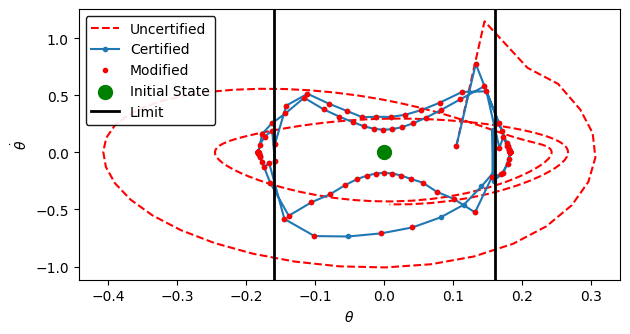

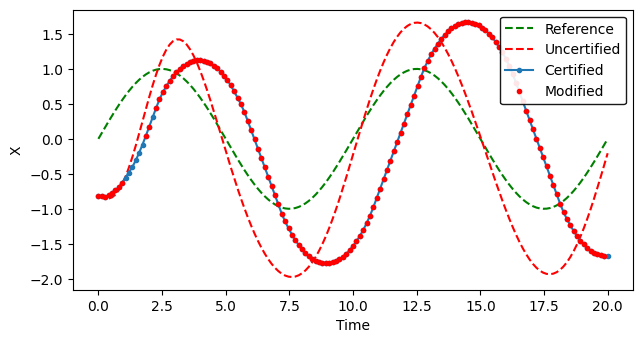

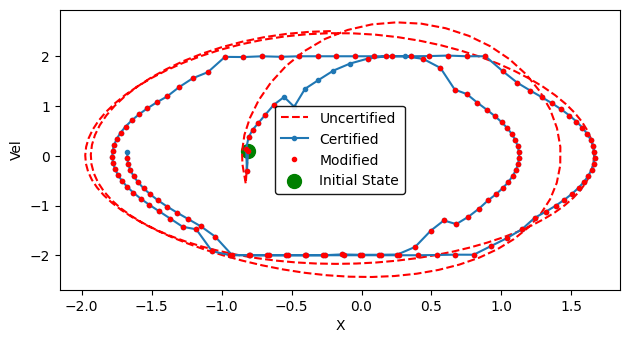

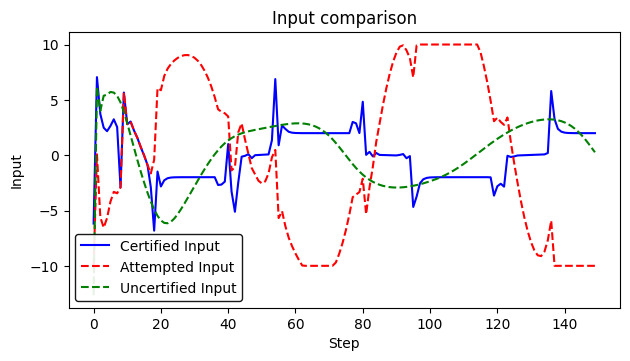

Total Uncertified Time: 0.1689012050628662s
Total Certified Time: 0.4754817485809326s
Number of Corrections:  143
Sum of Corrections:  109.11871913194038
Max Correction:  13.66357668933364
Number of Feasible Iterations:  150
Total Number of Iterations:  150.0
Total Number of Certified Iterations:  150.0
Number of Violations:  139.0
Number of Certified Violations:  94.0
RMSE Uncertified:  0.6860141092712029
RMSE Certified:  1.031680224687215


In [7]:
# =============================================================================
# Run Full Evaluation: Uncertified vs Certified + Video + Plots
# =============================================================================
from safe_control_gym.experiments.base_experiment import BaseExperiment
from safe_control_gym.envs.benchmark_env import Task
from IPython.display import Video, display

# Reset to default matplotlib style (same as adv_experiment.py)
plt.style.use('default')

def plot_results(config, uncert_results, uncert_metrics, cert_results, cert_metrics, safety_filter, elapsed_time_uncert, elapsed_time_cert):
    '''Plot the results of the experiment.'''
    mpsc_results = cert_results['safety_filter_data']
    corrections = mpsc_results['correction'][0] > 1e-6
    corrections = np.append(corrections, False)

    if config.task == Environment.CARTPOLE:
        graph1_1 = 2
        graph1_2 = 3
        graph3_1 = 0
        graph3_2 = 1
    elif config.task == Environment.QUADROTOR:
        graph1_1 = 4
        graph1_2 = 5
        graph3_1 = 0
        graph3_2 = 2

    _, ax = plt.subplots()
    ax.plot(uncert_results['obs'][0][:, graph1_1], uncert_results['obs'][0][:, graph1_2], 'r--', label='Uncertified')
    ax.plot(cert_results['obs'][0][:, graph1_1], cert_results['obs'][0][:, graph1_2], '.-', label='Certified')
    ax.plot(cert_results['obs'][0][corrections, graph1_1], cert_results['obs'][0][corrections, graph1_2], 'r.', label='Modified')
    ax.scatter(0, 0, color='g', marker='o', s=100, label='Initial State')
    if config.task == Environment.CARTPOLE:
        theta_constraint = config.task_config['constraints'][0].upper_bounds[2]
    elif config.task == Environment.QUADROTOR:
        theta_constraint = config.task_config['constraints'][0].upper_bounds[4]
    ax.axvline(x=-theta_constraint, color='k', lw=2, label='Limit')
    ax.axvline(x=theta_constraint, color='k', lw=2)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$\dot{\theta}$')
    ax.set_box_aspect(0.5)
    ax.legend(loc='best', framealpha=0.9, edgecolor='black')
    plt.tight_layout()
    plt.show()

    if config.task_config.task == Task.TRAJ_TRACKING and config.task == Environment.CARTPOLE:
        _, ax2 = plt.subplots()
        ax2.plot(np.linspace(0, 20, cert_results['obs'][0].shape[0]), safety_filter.env.X_GOAL[:cert_results['obs'][0].shape[0], 0], 'g--', label='Reference')
        ax2.plot(np.linspace(0, 20, uncert_results['obs'][0].shape[0]), uncert_results['obs'][0][:, 0], 'r--', label='Uncertified')
        ax2.plot(np.linspace(0, 20, cert_results['obs'][0].shape[0]), cert_results['obs'][0][:, 0], '.-', label='Certified')
        ax2.plot(np.linspace(0, 20, cert_results['obs'][0].shape[0])[corrections], cert_results['obs'][0][corrections, 0], 'r.', label='Modified')
        ax2.set_xlabel(r'Time')
        ax2.set_ylabel(r'X')
        ax2.set_box_aspect(0.5)
        ax2.legend(loc='best', framealpha=0.9, edgecolor='black')
        plt.tight_layout()
        plt.show()
    elif config.task == Environment.QUADROTOR:
        _, ax2 = plt.subplots()
        ax2.plot(uncert_results['obs'][0][:, 1], uncert_results['obs'][0][:, 3], 'r--', label='Uncertified')
        ax2.plot(cert_results['obs'][0][:, 1], cert_results['obs'][0][:, 3], '.-', label='Certified')
        ax2.plot(cert_results['obs'][0][corrections, 1], cert_results['obs'][0][corrections, 3], 'r.', label='Modified')
        ax2.set_xlabel(r'x_dot')
        ax2.set_ylabel(r'z_dot')
        ax2.set_box_aspect(0.5)
        ax2.legend(loc='best', framealpha=0.9, edgecolor='black')
        plt.tight_layout()
        plt.show()

    _, ax3 = plt.subplots()
    ax3.plot(uncert_results['obs'][0][:, graph3_1], uncert_results['obs'][0][:, graph3_2], 'r--', label='Uncertified')
    ax3.plot(cert_results['obs'][0][:, graph3_1], cert_results['obs'][0][:, graph3_2], '.-', label='Certified')
    if config.task_config.task == Task.TRAJ_TRACKING and config.task == Environment.QUADROTOR:
        ax3.plot(safety_filter.env.X_GOAL[:, 0], safety_filter.env.X_GOAL[:, 2], 'g--', label='Reference')
    ax3.plot(cert_results['obs'][0][corrections, graph3_1], cert_results['obs'][0][corrections, graph3_2], 'r.', label='Modified')
    ax3.scatter(uncert_results['obs'][0][0, graph3_1], uncert_results['obs'][0][0, graph3_2], color='g', marker='o', s=100, label='Initial State')
    ax3.set_xlabel(r'X')
    if config.task == Environment.CARTPOLE:
        ax3.set_ylabel(r'Vel')
    elif config.task == Environment.QUADROTOR:
        ax3.set_ylabel(r'Z')
    ax3.set_box_aspect(0.5)
    ax3.legend(loc='best', framealpha=0.9, edgecolor='black')
    plt.tight_layout()
    plt.show()

    _, ax_act = plt.subplots()
    if config.task == Environment.CARTPOLE:
        ax_act.plot(cert_results['current_physical_action'][0][:], 'b-', label='Certified Input')
        ax_act.plot(mpsc_results['uncertified_action'][0][:], 'r--', label='Attempted Input')
        ax_act.plot(uncert_results['current_physical_action'][0][:], 'g--', label='Uncertified Input')
    else:
        ax_act.plot(cert_results['current_physical_action'][0][:, 0], 'b-', label='Certified Input 1')
        ax_act.plot(cert_results['current_physical_action'][0][:, 1], 'b--', label='Certified Input 2')
        ax_act.plot(mpsc_results['uncertified_action'][0][:, 0], 'r-', label='Attempted Input 1')
        ax_act.plot(mpsc_results['uncertified_action'][0][:, 1], 'r--', label='Attempted Input 2')
        ax_act.plot(uncert_results['current_physical_action'][0][:, 0], 'g-', label='Uncertified Input 1')
        ax_act.plot(uncert_results['current_physical_action'][0][:, 1], 'g--', label='Uncertified Input 2')
    ax_act.legend(loc='best', framealpha=0.9, edgecolor='black')
    ax_act.set_title('Input comparison')
    ax_act.set_xlabel('Step')
    ax_act.set_ylabel('Input')
    ax_act.set_box_aspect(0.5)
    plt.tight_layout()
    plt.show()

    print(f'Total Uncertified Time: {elapsed_time_uncert}s')
    print(f'Total Certified Time: {elapsed_time_cert}s')
    print('Number of Corrections: ', np.sum(corrections))
    print('Sum of Corrections: ', np.linalg.norm(mpsc_results['correction'][0]))
    print('Max Correction: ', np.max(np.abs(mpsc_results['correction'][0])))
    print('Number of Feasible Iterations: ', np.sum(mpsc_results['feasible'][0]))
    print('Total Number of Iterations: ', uncert_metrics['average_length'])
    print('Total Number of Certified Iterations: ', cert_metrics['average_length'])
    print('Number of Violations: ', uncert_metrics['average_constraint_violation'])
    print('Number of Certified Violations: ', cert_metrics['average_constraint_violation'])
    print('RMSE Uncertified: ', uncert_metrics['average_rmse'])
    print('RMSE Certified: ', cert_metrics['average_rmse'])

# --- 1. Run UNCERTIFIED evaluation ---
print("=" * 60)
print("Running UNCERTIFIED evaluation...")
print("=" * 60)
task_kwargs_uncert = unmunchify(adv_config.task_config)
task_kwargs_uncert["gui"] = False
env_func_uncert = partial(make, adv_config.task, **task_kwargs_uncert)
env_uncert = env_func_uncert()

algo_kwargs_uncert = unmunchify(adv_config.algo_config)
algo_kwargs_uncert["output_dir"] = str(NOTEBOOK_DIR / "temp")
ctrl_uncert = make(adv_config.algo, env_func_uncert, **algo_kwargs_uncert)
ctrl_uncert.load(DEFAULT_LOG_DIR / "model_latest.pt")

experiment_uncert = BaseExperiment(env_uncert, ctrl_uncert)
uncert_results, uncert_metrics = experiment_uncert.run_evaluation(n_episodes=1)
elapsed_time_uncert = uncert_results['timestamp'][0][-1] - uncert_results['timestamp'][0][0]
ctrl_uncert.close()
env_uncert.close()

# --- 2. Run CERTIFIED evaluation with safety filter ---
print("\n" + "=" * 60)
print("Running CERTIFIED evaluation with safety filter...")
print("=" * 60)
task_kwargs_cert = unmunchify(adv_config.task_config)
task_kwargs_cert["gui"] = False
env_func_cert = partial(make, adv_config.task, **task_kwargs_cert)
env_cert = env_func_cert()

algo_kwargs_cert = unmunchify(adv_config.algo_config)
algo_kwargs_cert["output_dir"] = str(NOTEBOOK_DIR / "temp")
ctrl_cert = make(adv_config.algo, env_func_cert, **algo_kwargs_cert)
ctrl_cert.load(DEFAULT_LOG_DIR / "model_latest.pt")

task_kwargs_filter = unmunchify(adv_config.task_config)
task_kwargs_filter["normalized_rl_action_space"] = False
task_kwargs_filter["gui"] = False
env_func_filter = partial(make, adv_config.task, **task_kwargs_filter)
sf_kwargs = unmunchify(adv_config.sf_config)
safety_filter_eval = make(adv_config.safety_filter, env_func_filter, **sf_kwargs)
safety_filter_eval.reset()
ctrl_cert.reset()

experiment_cert = BaseExperiment(env_cert, ctrl_cert, safety_filter=safety_filter_eval)
cert_results, cert_metrics = experiment_cert.run_evaluation(n_episodes=1)
elapsed_time_cert = cert_results['timestamp'][0][-1] - cert_results['timestamp'][0][0]

# --- 3. Generate and display video ---
print("\n" + "=" * 60)
print("Generating rollout video...")
print("=" * 60)
rollout_outputs = generate_cartpole_rollout(
    adv_config,
    max_steps=600,
    fps=20,
    outfile=DEFAULT_OUTPUT_DIR / "cartpole_rollout.gif",
    video_formats=("gif", "mp4"),
)
mp4_path = rollout_outputs.get("mp4")
gif_path = rollout_outputs.get("gif")
print(f"Video saved to: {mp4_path or gif_path}")
display(Video(filename=str(mp4_path), html_attributes="controls loop"))

# --- 4. Plot results ---
print("\n" + "=" * 60)
print("EXPERIMENT RESULTS")
print("=" * 60)
plot_results(adv_config, uncert_results, uncert_metrics, cert_results, cert_metrics, 
             safety_filter_eval, elapsed_time_uncert, elapsed_time_cert)

# Cleanup
ctrl_cert.close()
safety_filter_eval.close()
env_cert.close()